# 🎙️ Speech Emotion Recognition
### CNN-based Binary Classifier: Happy vs Sad
#### RAVDESS + CREMA-D | Google Drive Dataset

## 1. Install Dependencies

In [1]:
!pip install -q librosa soundfile tensorflow scikit-learn pandas matplotlib seaborn

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


## 3. Imports

In [3]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from pathlib import Path
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings('ignore')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
GPU        : True


## 4. Constants & Paths

In [4]:
# ── Dataset Paths (Google Drive) ───────────────────────────────────
BASE_DIR    = '/content/drive/MyDrive/SER_Project/data'
RAVDESS_DIR = '/content/drive/MyDrive/SER_Project/data/RAVDESS'
CREMA_DIR   = '/content/drive/MyDrive/SER_Project/data/CREMA-D'

# ── Audio ──────────────────────────────────────────────────────────
SAMPLE_RATE  = 22050
DURATION     = 3
N_MELS       = 128
IMG_SIZE     = (128, 128)
INPUT_SHAPE  = (128, 128, 1)

# ── Training ───────────────────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 60
LR           = 0.0002
VAL_SPLIT    = 0.15
TEST_SIZE    = 0.15
RANDOM_SEED  = 42

# ── Activations ────────────────────────────────────────────────────
ACTIVATIONS  = ['relu', 'tanh', 'leaky_relu', 'gelu', 'swish']

# ── Label maps ─────────────────────────────────────────────────────
RAVDESS_MAP  = {'03': 'happy', '04': 'sad'}
CREMA_MAP    = {'HAP': 'happy', 'SAD': 'sad'}

os.makedirs('checkpoints', exist_ok=True)
print('Constants set.')

Constants set.


## 5. Dataset Loader (RAVDESS + CREMA-D)

In [5]:
def load_ravdess(ravdess_dir: str):
    """
    Recursively loads happy/sad .wav files from the RAVDESS Actor_XX folder structure.
    Filename format: 03-01-03-01-01-01-01.wav  → index [2] = emotion code
    Returns (file_paths, labels).
    """
    file_paths, labels = [], []
    ravdess_path = Path(ravdess_dir)

    if not ravdess_path.exists():
        print(f'  [RAVDESS] Directory not found: {ravdess_dir}')
        return [], []

    for wav in ravdess_path.rglob('*.wav'):
        name   = wav.stem
        parts  = name.split('-')
        if len(parts) != 7:
            continue
        code   = parts[2]
        emotion = RAVDESS_MAP.get(code)
        if emotion is None:
            continue
        file_paths.append(str(wav))
        labels.append(emotion)

    return file_paths, labels


def load_cremad(crema_dir: str):
    """
    Loads happy/sad .wav files from the CREMA-D flat folder.
    Filename format: 1001_DFA_HAP_XX.wav  → split by '_', index [2] = emotion code
    Returns (file_paths, labels).
    """
    file_paths, labels = [], []
    crema_path = Path(crema_dir)

    if not crema_path.exists():
        print(f'  [CREMA-D] Directory not found: {crema_dir}')
        return [], []

    for wav in crema_path.rglob('*.wav'):
        name   = wav.stem
        parts  = name.split('_')
        if len(parts) < 3:
            continue
        code   = parts[2].upper()
        emotion = CREMA_MAP.get(code)
        if emotion is None:
            continue
        file_paths.append(str(wav))
        labels.append(emotion)

    return file_paths, labels


def load_all_datasets():
    """
    Loads both RAVDESS and CREMA-D, merges, prints summary.
    Raises SystemExit if no valid files are found.
    """
    print('Loading RAVDESS ...')
    rav_fps, rav_lbls = load_ravdess(RAVDESS_DIR)
    print(f'  RAVDESS files used : {len(rav_fps)}')

    print('Loading CREMA-D ...')
    cre_fps, cre_lbls = load_cremad(CREMA_DIR)
    print(f'  CREMA-D files used : {len(cre_fps)}')

    file_paths = rav_fps + cre_fps
    labels     = rav_lbls + cre_lbls

    print(f'\nTotal files        : {len(file_paths)}')

    if len(file_paths) == 0:
        print('[ERROR] No valid audio files found in either dataset.')
        print('        Check that your Google Drive paths are correct and files exist.')
        raise SystemExit('Dataset is empty — stopping notebook execution.')

    dist = pd.Series(labels).value_counts()
    print('\nClass distribution:')
    print(dist.to_string())

    return file_paths, labels


file_paths, labels = load_all_datasets()

Loading RAVDESS ...
  RAVDESS files used : 768
Loading CREMA-D ...
  CREMA-D files used : 2542

Total files        : 3310

Class distribution:
happy    1655
sad      1655


## 6. Audio Processing

In [6]:
def load_audio(file_path: str, sr: int = SAMPLE_RATE, duration: float = DURATION):
    """Load and pad/trim audio to fixed length. Returns None on failure."""
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        target_len = int(sr * duration)
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        else:
            y = y[:target_len]
        return y
    except Exception as e:
        print(f'  [SKIP] {file_path}: {e}')
        return None


def audio_to_spectrogram(y: np.ndarray,
                          sr: int   = SAMPLE_RATE,
                          n_mels: int = N_MELS,
                          img_size: tuple = IMG_SIZE):
    """Waveform → normalised Mel Spectrogram of shape (H, W, 1)."""
    mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db  = librosa.power_to_db(mel, ref=np.max)

    # Resize to fixed spatial size
    mel_resized = tf.image.resize(
        mel_db[..., np.newaxis], img_size
    ).numpy()  # (128, 128, 1)

    # Per-sample min-max normalisation → [0, 1]for stability and faster learning
    mn, mx = mel_resized.min(), mel_resized.max()
    if mx - mn > 1e-6:
        mel_resized = (mel_resized - mn) / (mx - mn)
    else:
        mel_resized = np.zeros_like(mel_resized)

    return mel_resized.astype(np.float32)


print('Audio processing functions defined.')

Audio processing functions defined.


## 7. Data Augmentation (Train Only)

In [7]:
def augment_audio(y: np.ndarray, sr: int = SAMPLE_RATE):
    """
    Returns list of augmented waveforms (including original).
    Applied ONLY to training data — never to test data.
    """
    augmented = [y]
    target    = len(y)

    # ── Time stretch ×2
    for rate in [0.9, 1.1]:
        try:
            s = librosa.effects.time_stretch(y, rate=rate)
            s = np.pad(s, (0, max(0, target - len(s))))[:target]
            augmented.append(s)
        except Exception:
            pass

    # ── Pitch shift ×2
    for steps in [1, -1]:
        try:
            augmented.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=steps))
        except Exception:
            pass

    # ── Gaussian noise
    augmented.append(y + 0.005 * np.random.randn(len(y)).astype(np.float32))

    # ── Volume scaling ×2
    for scale in [0.9, 1.1]:
        augmented.append(y * scale)

    return augmented


print('Augmentation functions defined.')

Augmentation functions defined.


## 8. Dataset Builder

In [8]:
LABEL_TO_INT = {'happy': 0, 'sad': 1}

#Datset loaded and augmented , convereted to mel and then each emotion is num
def build_dataset(file_paths, labels, augment: bool = False):
    """
    Loads audio, optionally augments (train only), converts to spectrograms.
    Returns (X: float32 ndarray, y: int32 ndarray).
    """
    X, y = [], []

    for fp, lbl in zip(file_paths, labels):
        audio = load_audio(fp)
        if audio is None:
            continue

        samples = augment_audio(audio) if augment else [audio]

        for sample in samples:
            X.append(audio_to_spectrogram(sample))
            y.append(LABEL_TO_INT[lbl])

    if len(X) == 0:
        return np.array([]), np.array([])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


print('Dataset builder defined.')

Dataset builder defined.


## 9. Train / Test Split

In [9]:
# Stratified split BEFORE augmentation
train_fps, test_fps, train_lbls, test_lbls = train_test_split(
    file_paths, labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=labels
)

print(f'Train files : {len(train_fps)}')
print(f'Test  files : {len(test_fps)}')

print('\nBuilding TRAIN set (with augmentation) ...')
X_train, y_train = build_dataset(train_fps, train_lbls, augment=True)

print('Building TEST  set (no augmentation)  ...')
X_test,  y_test  = build_dataset(test_fps,  test_lbls,  augment=False)

if X_train.size == 0 or X_test.size == 0:
    raise SystemExit('[STOP] No valid samples after processing — check audio files.')

print(f'\nX_train : {X_train.shape}  |  y_train dist: {np.bincount(y_train)}')
print(f'X_test  : {X_test.shape}   |  y_test  dist: {np.bincount(y_test)}')

Train files : 2813
Test  files : 497

Building TRAIN set (with augmentation) ...
Building TEST  set (no augmentation)  ...

X_train : (22504, 128, 128, 1)  |  y_train dist: [11248 11256]
X_test  : (497, 128, 128, 1)   |  y_test  dist: [249 248]


## 10. Model Builder

In [10]:
def get_activation(name: str):
    """Return a Keras activation layer by name string."""
    n = name.lower()
    if n == 'relu'       : return layers.ReLU()
    if n == 'tanh'       : return layers.Activation('tanh')
    if n == 'leaky_relu' : return layers.LeakyReLU(negative_slope=0.1)
    if n == 'gelu'       : return layers.Activation('gelu')
    if n == 'swish'      : return layers.Activation('swish')
    return layers.ReLU()


def build_cnn(activation: str = 'relu',
              input_shape: tuple = INPUT_SHAPE,
              l2_reg: float = 1e-4):
    reg = regularizers.l2(l2_reg)
    inp = keras.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = get_activation(activation)(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.2)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = get_activation(activation)(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = get_activation(activation)(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = get_activation(activation)(x)
    x = layers.Dropout(0.5)(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, kernel_regularizer=reg)(x)
    x = get_activation(activation)(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name=f'CNN_{activation}')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Sanity check
demo = build_cnn('relu')
demo.summary()
del demo

Model: "CNN_relu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 11. Training Loop (All Activations)

In [11]:
histories   = {}
models      = {}
predictions = {}

for act in ACTIVATIONS:
    print(f'\n{"="*55}')
    print(f'  Training  →  activation = {act}')
    print(f'{"="*55}')

    model = build_cnn(act)

    callbacks = [
        EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=f'checkpoints/best_{act}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=VAL_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    histories[act]   = history
    models[act]      = model
    predictions[act] = (model.predict(X_test, verbose=0) >= 0.5).astype(int).flatten()

    print(f'  Finished: {act}')

print('\nAll models trained!')


  Training  →  activation = relu
Epoch 1/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 43s 48ms/step - accuracy: 0.7450 - loss: 0.5560 - val_accuracy: 0.7029 - val_loss: 0.6376 - learning_rate: 2.0000e-04
Epoch 2/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8185 - loss: 0.4429 - val_accuracy: 0.6253 - val_loss: 0.9637 - learning_rate: 2.0000e-04
Epoch 3/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8395 - loss: 0.4057 - val_accuracy: 0.7989 - val_loss: 0.5074 - learning_rate: 2.0000e-04
Epoch 4/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8515 - loss: 0.3844 - val_accuracy: 0.8344 - val_loss: 0.3985 - learning_rate: 2.0000e-04
Epoch 5/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8619 - loss: 0.3661 - val_accuracy: 0.7935 - val_loss: 0.5180 - learning_rate: 2.0000e-04
Epoch 6/60
598/598 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.8680 - loss: 0.3511 - val_accuracy: 0.8392 - val_loss: 0.4059 - learning_rate: 2.0000e-04
Epoch 7/60
598/598

## 12. Evaluation

In [12]:
results = {}

for act in ACTIVATIONS:
    print(f'\n{"-"*50}')
    print(f'  Evaluation  →  {act}')
    print(f'{"-"*50}')

    loss, acc = models[act].evaluate(X_test, y_test, verbose=0)
    print(f'  Test Accuracy : {acc*100:.2f}%')
    print(f'  Test Loss     : {loss:.4f}')

    print('\n  Classification Report:')
    print(classification_report(
        y_test, predictions[act],
        target_names=['happy', 'sad']
    ))

    val_acc_hist   = histories[act].history.get('val_accuracy', [0])
    best_val_acc   = max(val_acc_hist)
    epochs_trained = len(histories[act].history['loss'])

    results[act] = {
        'Test Accuracy %'      : round(acc * 100, 2),
        'Validation Accuracy %': round(best_val_acc * 100, 2),
        'Test Loss'            : round(loss, 4),
        'Epochs Trained'       : epochs_trained,
        'confusion_matrix'     : confusion_matrix(y_test, predictions[act])
    }


--------------------------------------------------
  Evaluation  →  relu
--------------------------------------------------
  Test Accuracy : 93.56%
  Test Loss     : 0.2106

  Classification Report:
              precision    recall  f1-score   support

       happy       0.91      0.96      0.94       249
         sad       0.96      0.91      0.93       248

    accuracy                           0.94       497
   macro avg       0.94      0.94      0.94       497
weighted avg       0.94      0.94      0.94       497


--------------------------------------------------
  Evaluation  →  tanh
--------------------------------------------------
  Test Accuracy : 87.32%
  Test Loss     : 0.3120

  Classification Report:
              precision    recall  f1-score   support

       happy       0.86      0.90      0.88       249
         sad       0.89      0.85      0.87       248

    accuracy                           0.87       497
   macro avg       0.87      0.87      0.87       497

## 13. Visualization

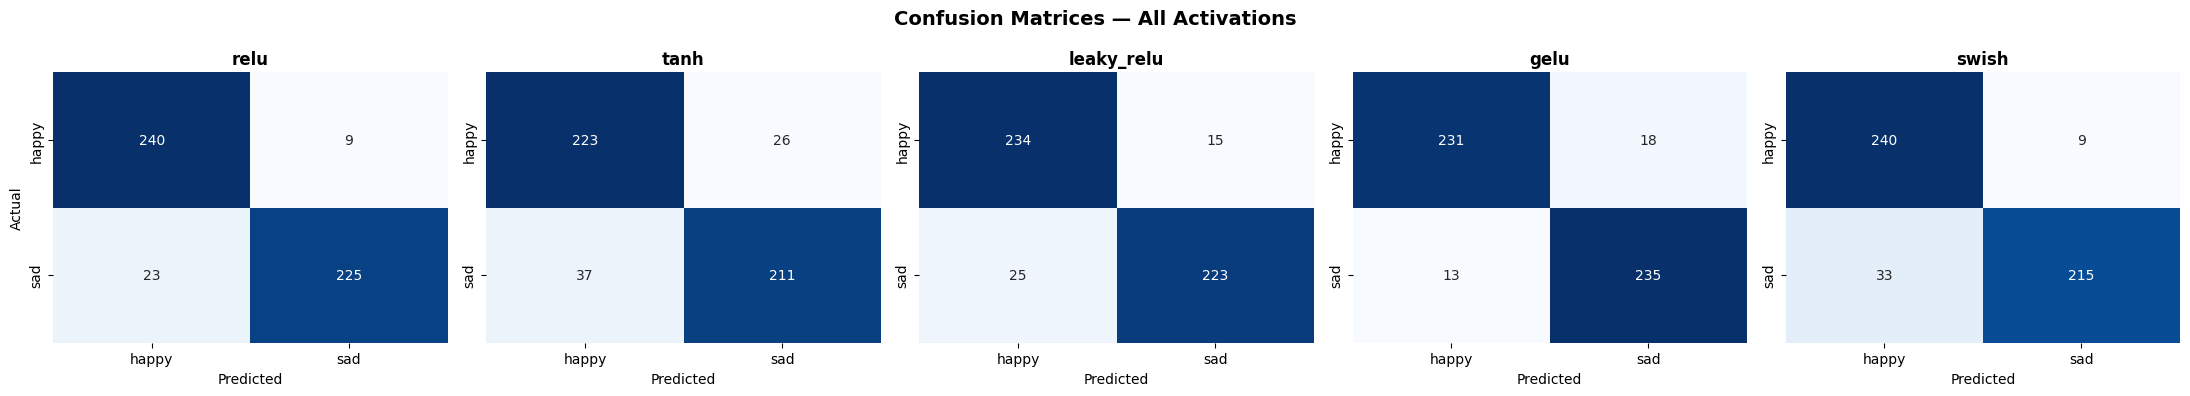

In [13]:
# ── 13a. Combined Confusion Matrix Grid (1 row × 5 columns) ──────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrices — All Activations', fontsize=14, fontweight='bold')

for i, act in enumerate(ACTIVATIONS):
    cm = results[act]['confusion_matrix']
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['happy', 'sad'],
        yticklabels=['happy', 'sad'],
        ax=axes[i], cbar=False
    )
    axes[i].set_title(act, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual' if i == 0 else '')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

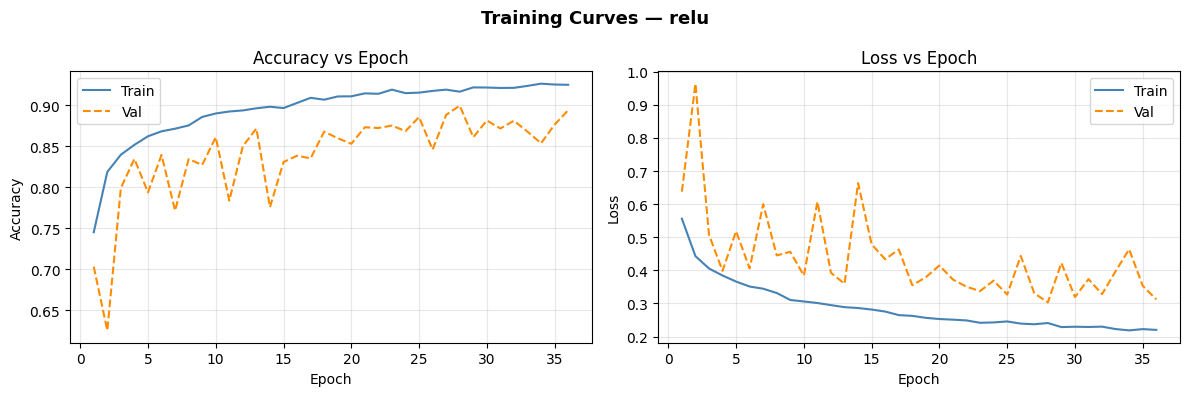

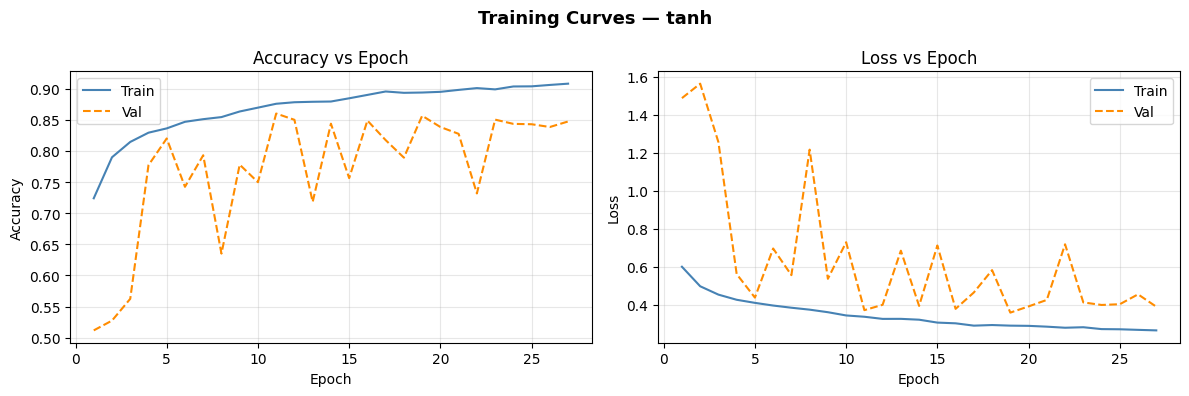

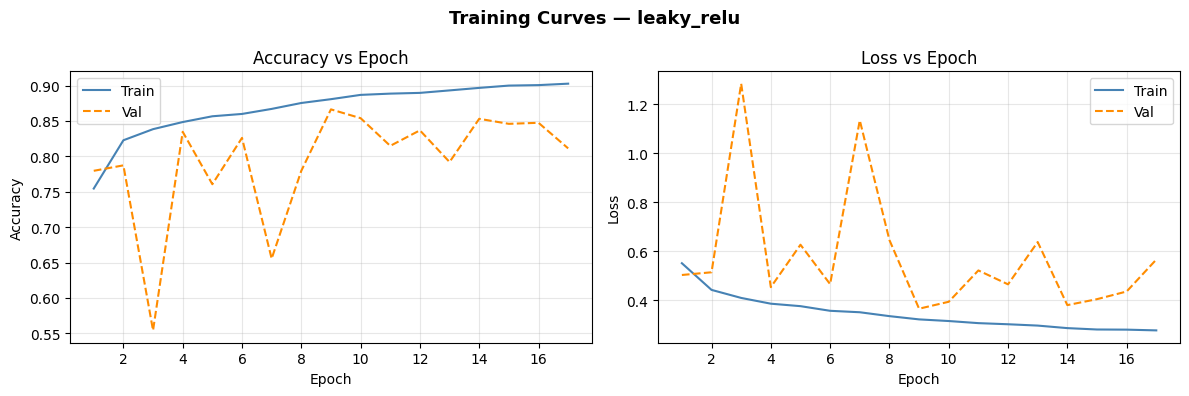

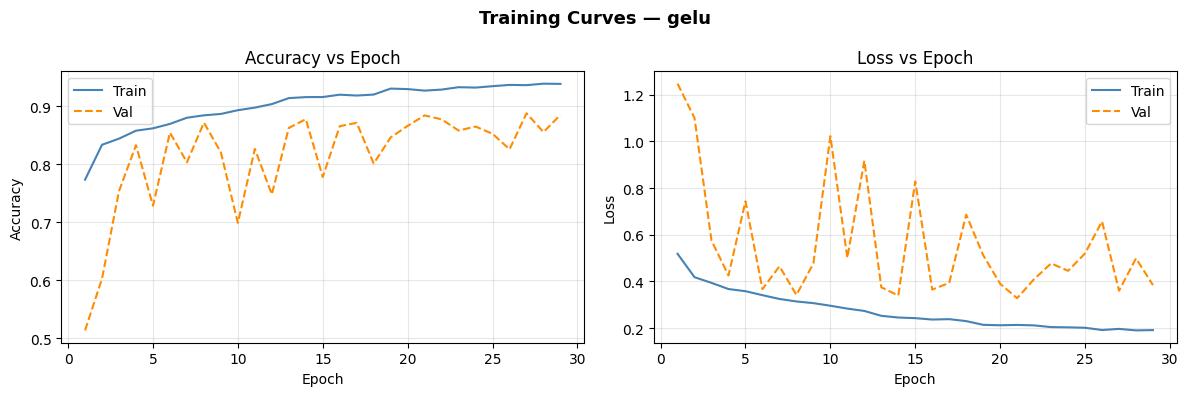

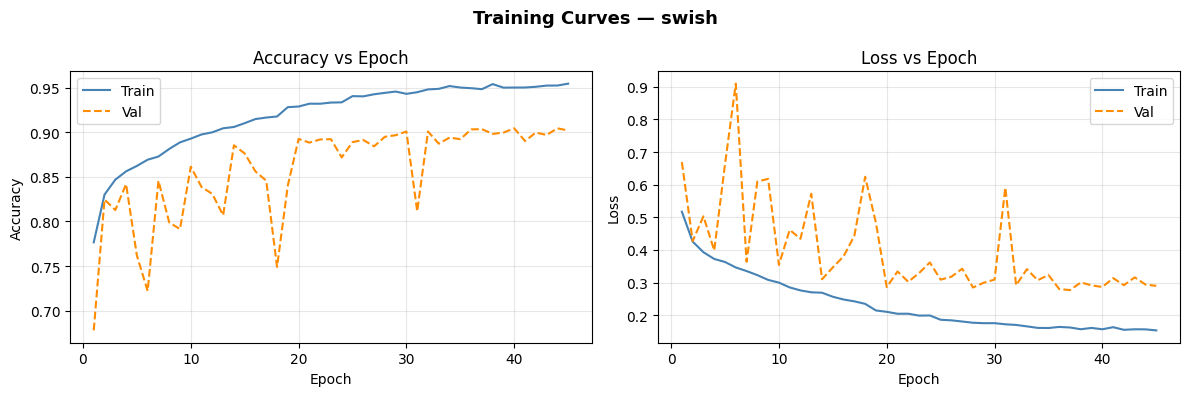

In [14]:
# ── 13b. Training Curves — per model ────────────────────────────
for act in ACTIVATIONS:
    h = histories[act].history
    ep = range(1, len(h['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training Curves — {act}', fontsize=13, fontweight='bold')

    axes[0].plot(ep, h['accuracy'],     label='Train', color='steelblue')
    axes[0].plot(ep, h['val_accuracy'], label='Val',   color='darkorange', linestyle='--')
    axes[0].set_title('Accuracy vs Epoch')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, h['loss'],     label='Train', color='steelblue')
    axes[1].plot(ep, h['val_loss'], label='Val',   color='darkorange', linestyle='--')
    axes[1].set_title('Loss vs Epoch')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'curves_{act}.png', dpi=120, bbox_inches='tight')
    plt.show()

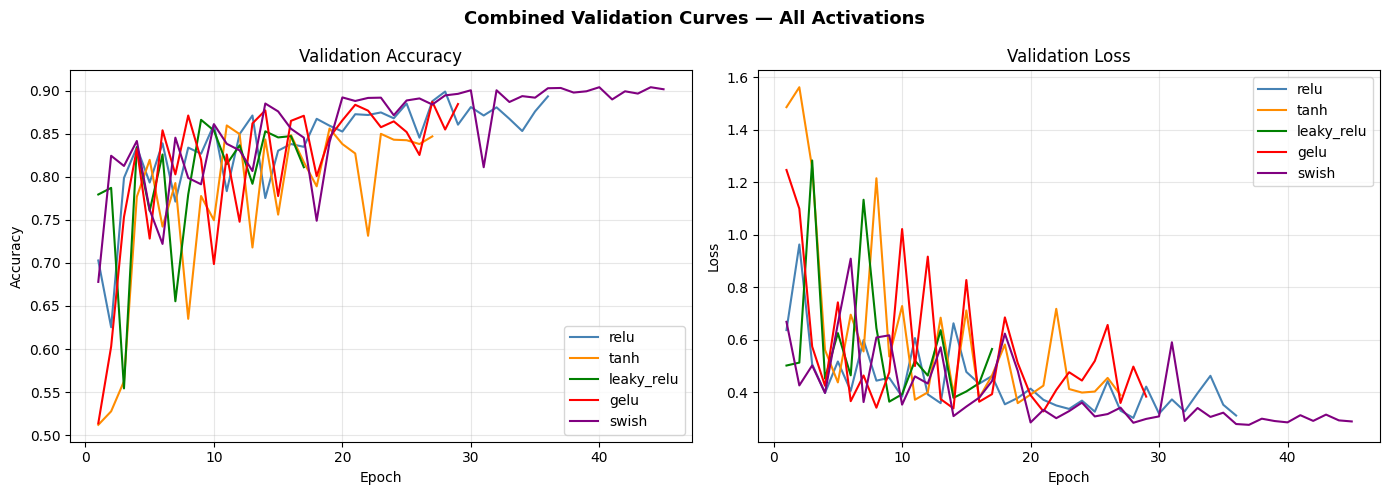

In [15]:
# ── 13c. Combined Validation Curves — all 5 models ──────────────
COLORS = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Combined Validation Curves — All Activations', fontsize=13, fontweight='bold')

for act, col in zip(ACTIVATIONS, COLORS):
    h  = histories[act].history
    ep = range(1, len(h['val_accuracy']) + 1)
    axes[0].plot(ep, h['val_accuracy'], label=act, color=col)
    axes[1].plot(ep, h['val_loss'],     label=act, color=col)

axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('combined_val_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 14. Comparison Table + Bar Chart

In [16]:
# ── 14a. Styled Comparison Table ────────────────────────────────
table_rows = []
for act in ACTIVATIONS:
    r = results[act]
    table_rows.append({
        'Activation'           : act,
        'Test Accuracy %'      : r['Test Accuracy %'],
        'Validation Accuracy %': r['Validation Accuracy %'],
        'Test Loss'            : r['Test Loss'],
        'Epochs Trained'       : r['Epochs Trained']
    })

df_results = pd.DataFrame(table_rows).set_index('Activation')

styled = (
    df_results.style
    .background_gradient(cmap='YlGn',     subset=['Test Accuracy %', 'Validation Accuracy %'])
    .background_gradient(cmap='YlOrRd_r', subset=['Test Loss'])
    .format({
        'Test Accuracy %'      : '{:.2f}',
        'Validation Accuracy %': '{:.2f}',
        'Test Loss'            : '{:.4f}',
        'Epochs Trained'       : '{:d}'
    })
    .set_caption('Model Comparison — All Activations')
    .set_table_styles([{'selector': 'caption',
                        'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
)
display(styled)

,Test Accuracy %,Validation Accuracy %,Test Loss,Epochs Trained
Activation,,,,
relu,93.56,89.93,0.2106,36
tanh,87.32,85.99,0.3120,27
leaky_relu,91.95,86.64,0.2496,17
gelu,93.76,88.74,0.2132,29
swish,91.55,90.43,0.2237,45


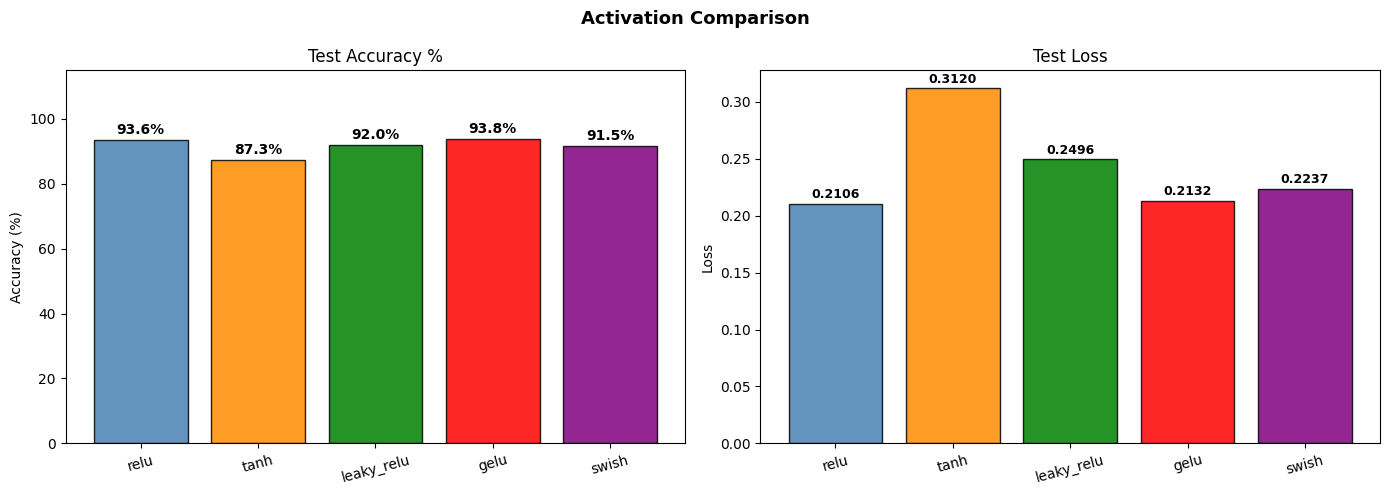

In [17]:
# ── 14b. Bar Chart Comparison ────────────────────────────────────
accs   = [results[a]['Test Accuracy %'] for a in ACTIVATIONS]
losses = [results[a]['Test Loss']       for a in ACTIVATIONS]
x      = np.arange(len(ACTIVATIONS))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Activation Comparison', fontsize=13, fontweight='bold')

bars1 = axes[0].bar(x, accs, color=COLORS, alpha=0.85, edgecolor='black')
axes[0].set_title('Test Accuracy %')
axes[0].set_xticks(x); axes[0].set_xticklabels(ACTIVATIONS, rotation=15)
axes[0].set_ylim(0, 115); axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(x, losses, color=COLORS, alpha=0.85, edgecolor='black')
axes[1].set_title('Test Loss')
axes[1].set_xticks(x); axes[1].set_xticklabels(ACTIVATIONS, rotation=15)
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('bar_chart_comparison.png', dpi=120, bbox_inches='tight')
plt.show()